# Publication-Ready EDA for Arabic Deepfake Detection (Train Split Only)

A **minimal, CPU-only, local-first** notebook for exploratory data analysis.

Key outputs:
- Dataset overview and label balance
- Text length distributions
- Training-split signal prevalence heatmaps (Real vs Fake)
- Optional deception subtype distribution


## 1) Setup & Local Paths

In [1]:
import gc
import importlib
import json
import os
import random
import re
import string
import sys
import time
import unicodedata
import warnings
from datetime import datetime
from pathlib import Path

from pathlib import Path
import os
import re
import math
import warnings
from collections import Counter
import emoji

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Display helper (works in Jupyter and standalone)
try:
    from IPython.display import display
except ImportError:
    display = print

warnings.filterwarnings("ignore", category=FutureWarning)

# ---------------------------------------------------------------------------
# Path detection: local-first, with optional DATASET_ROOT override
# ---------------------------------------------------------------------------
def find_project_root(start: Path, marker: str = "Dataset") -> Path:
    """Walk up from start looking for a folder containing 'marker'."""
    for parent in [start] + list(start.parents):
        if (parent / marker).exists():
            return parent
    return start

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = find_project_root(NOTEBOOK_DIR)
DATASET_ROOT = Path(os.environ.get("DATASET_ROOT", PROJECT_ROOT / "Dataset"))

# Output directory
OUTPUT_ROOT = NOTEBOOK_DIR / "Output" / "eda"
for sub in ["figures", "tables"]:
    (OUTPUT_ROOT / sub).mkdir(parents=True, exist_ok=True)

# Training data paths
TWITTER_TRAIN_PATH = DATASET_ROOT / "Twitter_data" / "Twitter_data" / "splits_rebuilt_v4" / "train_with_meta.csv"
YOUTUBE_TRAIN_PATH = DATASET_ROOT / "Youtube_data" / "Youtube_data" / "splits_rebuilt" / "train_with_meta.csv"

# Load training data
if not TWITTER_TRAIN_PATH.exists():
    raise FileNotFoundError(f"Twitter train not found: {TWITTER_TRAIN_PATH}")
if not YOUTUBE_TRAIN_PATH.exists():
    raise FileNotFoundError(f"YouTube train not found: {YOUTUBE_TRAIN_PATH}")

twitter_train = pd.read_csv(TWITTER_TRAIN_PATH)
youtube_train = pd.read_csv(YOUTUBE_TRAIN_PATH)

print(f"PROJECT_ROOT:  {PROJECT_ROOT}")
print(f"DATASET_ROOT:  {DATASET_ROOT}")
print(f"OUTPUT_ROOT:   {OUTPUT_ROOT}")
print(f"Twitter train: {len(twitter_train):,} rows")
print(f"YouTube train: {len(youtube_train):,} rows")


PROJECT_ROOT:  c:\Users\ahrhq\OneDrive - KFUPM\GADD\GADD_Project
DATASET_ROOT:  c:\Users\ahrhq\OneDrive - KFUPM\GADD\GADD_Project\Dataset
OUTPUT_ROOT:   c:\Users\ahrhq\OneDrive - KFUPM\GADD\GADD_Project\Final_Pipeline\Output\eda
Twitter train: 19,800 rows
YouTube train: 19,790 rows


## 2) Lightweight Style Helpers

In [2]:
import matplotlib.font_manager as fm


PLOT_FONT_PRIORITY = [
    "Computer Modern Roman",
    "CMU Serif",
    "Latin Modern Roman",
    "cmr10",
]
PLOT_FONT_FALLBACKS = ["DejaVu Serif"]



def resolve_publication_font_stack():
    available = {font.name for font in fm.fontManager.ttflist}
    stack = [name for name in PLOT_FONT_PRIORITY if name in available]
    if not stack:
        stack = [PLOT_FONT_FALLBACKS[0]]
    return stack + [name for name in PLOT_FONT_PRIORITY if name not in stack] + PLOT_FONT_FALLBACKS


PUBLICATION_FONT_STACK = resolve_publication_font_stack()



def apply_paper_style():
    """Apply a clean publication style with a Computer Modern-first stack."""
    sns.set_theme(style="white", palette="colorblind", rc={"axes.grid": False})
    plt.rcParams.update({
        "font.family": "serif",
        "font.serif": PUBLICATION_FONT_STACK,
        "mathtext.fontset": "cm",
        "mathtext.default": "regular",
        "axes.formatter.use_mathtext": True,
        "axes.unicode_minus": False,
        "font.size": 10,
        "axes.titlesize": 12,
        "axes.labelsize": 10,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
        "legend.fontsize": 9,
        "figure.dpi": 100,
        "savefig.dpi": 300,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.edgecolor": "#2F2F2F",
        "axes.linewidth": 0.8,
        "axes.facecolor": "white",
        "figure.facecolor": "white",
        "savefig.facecolor": "white",
        "text.color": "#1F1F1F",
        "axes.labelcolor": "#1F1F1F",
        "xtick.color": "#1F1F1F",
        "ytick.color": "#1F1F1F",
    })



def save_figure(fig, name: str, formats=("png", "pdf")):
    """Save figure to OUTPUT_ROOT/figures/ in multiple formats."""
    paths = []
    for fmt in formats:
        path = OUTPUT_ROOT / "figures" / f"{name}.{fmt}"
        fig.savefig(path, bbox_inches="tight", facecolor="white")
        paths.append(path)
    return paths



def save_table(df, name: str):
    """Save DataFrame to OUTPUT_ROOT/tables/ as CSV."""
    path = OUTPUT_ROOT / "tables" / f"{name}.csv"
    df.to_csv(path, index=False)
    return path


apply_paper_style()
print(f"Style helpers ready. Computer Modern-first stack: {PUBLICATION_FONT_STACK[0]}")

Style helpers ready. Computer Modern-first stack: cmr10


## Preprocessing Example Sentences

This section provides a compact, CPU-only illustration of how short Twitter and YouTube sentences change under the notebook's three explanatory preprocessing views: `manual`, `advanced`, and `deepfake_aware`.

The helper layer below copies the live notebook normalization primitives directly where they exist, keeps the section self-contained, and exports two small CSV tables for paper-ready reference.

In [3]:
# SPECIAL TOKEN REGISTRATION AND SIGNAL PATTERNS

SPECIAL_TOKENS = {
    "url": "<URL>",
    "mention": "<MENTION>",
    "hashtag": "<HASHTAG>",
    "number": "<NUMBER>",
    "latin": "<LATIN>",
}
ALL_SPECIAL_TOKENS_LIST = [SPECIAL_TOKENS[key] for key in ("url", "mention", "hashtag", "number", "latin")]
TOKENIZER_LEVEL_SPECIAL_TOKENS = {"<UNK>", "<pad>"}
SPECIAL_TOKEN_PATTERN = re.compile(r"(<URL>|<MENTION>|<HASHTAG>|<NUMBER>|<LATIN>)")
ARABIC_DIACRITICS_PATTERN = re.compile(r"[\u064B-\u065F\u0670]")
TATWEEL_CHAR = "\u0640"
ARABIC_INDIC_DIGITS = "٠١٢٣٤٥٦٧٨٩"
EASTERN_ARABIC_DIGITS = "۰۱۲۳۴۵۶۷۸۹"
ALEF_VARIANTS = {"أ": "ا", "إ": "ا", "آ": "ا", "ٱ": "ا"}
YEH_VARIANTS = {"ى": "ي", "ی": "ي"}
HAMZA_VARIANTS = {"ؤ": "و", "ئ": "ي"}
URL_PATTERN = re.compile(r"(?:https?://\S+|www\.\S+)", flags=re.IGNORECASE)
MENTION_PATTERN = re.compile(r"(?<!\w)@[A-Za-z0-9_]+")
HASHTAG_PATTERN = re.compile(r"(?<!\w)#[\w\u0600-\u06FF\u0750-\u077F\u08A0-\u08FF_]+")
ENGLISH_PATTERN = re.compile(r"[A-Za-z]+(?:[A-Za-z0-9_./+-]*[A-Za-z0-9])?")
NUMBER_SPAN_PATTERN = re.compile(r"(?<!\w)[\d\u0660-\u0669\u06F0-\u06F9]+(?:[.,:/\-][\d\u0660-\u0669\u06F0-\u06F9]+)*(?:[%٪])?")
HTML_TAG_PATTERN = re.compile(r"</?[^>\n]+>")
HTML_ENTITY_PATTERN = re.compile(r"&(?:[A-Za-z]+|#\d+|#x[0-9A-Fa-f]+);")
INVISIBLE_FORMATTING_PATTERN = re.compile(r"[\u200b-\u200f\u202a-\u202e\u2060-\u206f\ufeff]")
REPEATED_SEPARATOR_PATTERN = re.compile(r"([\-_=+~*#|/\\])\1+")
MINIMAL_PUNCT = "\u060C.\u061F"
ASCII_PUNCT = string.punctuation


def get_required_special_tokens(preprocessing_method):
    if preprocessing_method == "deepfake_aware":
        return [tok for tok in ALL_SPECIAL_TOKENS_LIST if tok not in TOKENIZER_LEVEL_SPECIAL_TOKENS]
    return []


print("Twitter special-token registry defined.")

Twitter special-token registry defined.


In [4]:
def is_arabic_char(ch):
    """Check if character is Arabic (including extended ranges)."""
    code = ord(ch)
    return (
        (0x0600 <= code <= 0x06FF) or  # Arabic
        (0x0750 <= code <= 0x077F) or  # Arabic Supplement
        (0x08A0 <= code <= 0x08FF) or  # Arabic Extended-A
        (0xFB50 <= code <= 0xFDFF) or  # Arabic Presentation Forms-A
        (0xFE70 <= code <= 0xFEFF)     # Arabic Presentation Forms-B
    )

def is_english_char(ch):
    """Check if character is English letter."""
    return ('A' <= ch <= 'Z') or ('a' <= ch <= 'z')

def is_arabic_script_word(word):
    """
    Check if word is primarily Arabic script.
    Returns True if >50% of alphanumeric characters are Arabic.
    """
    if not word:
        return False

    arabic_count = sum(1 for ch in word if is_arabic_char(ch))
    total_alpha = sum(1 for ch in word if ch.isalnum())

    if total_alpha == 0:
        return False

    return (arabic_count / total_alpha) >= 0.5


def is_english_script_word(word):
    """
    Check if word is primarily English (Latin) script.
    Returns True if >50% of alphanumeric characters are English letters.
    """
    if not word:
        return False

    english_count = sum(1 for ch in word if is_english_char(ch))
    total_alpha = sum(1 for ch in word if ch.isalnum())

    if total_alpha == 0:
        return False

    return (english_count / total_alpha) >= 0.5


def detect_script_category(word):
    """
    Categorize word by script type.

    Returns:
        'arabic' | 'english' | 'other' | 'number' | 'unknown'
    """
    if not word or not word.strip():
        return 'unknown'

    word = word.strip()

    # Check if it's a number (Western or Arabic-Indic digits)
    if any(ch.isdigit() or ch in ARABIC_INDIC_DIGITS + EASTERN_ARABIC_DIGITS for ch in word):
        # Contains digits - categorize as number
        return 'number'

    if is_arabic_script_word(word):
        return 'arabic'
    elif is_english_script_word(word):
        return 'english'
    elif any(ch.isalpha() for ch in word):
        # Has letters but not Arabic/English
        return 'other'
    else:
        return 'unknown'

In [5]:
def safe_str(text):
    if pd.isna(text):
        return ""
    return str(text)


def strip_html_like(text):
    text = safe_str(text)
    text = HTML_TAG_PATTERN.sub(" ", text)
    return HTML_ENTITY_PATTERN.sub(" ", text)


def remove_invisible_and_control_chars(text):
    cleaned = []
    for ch in safe_str(text):
        if INVISIBLE_FORMATTING_PATTERN.match(ch):
            continue
        if unicodedata.category(ch) in {"Cf", "Cc", "Cs"} and ch not in {"\n", "\t", "\r"}:
            continue
        cleaned.append(ch)
    return "".join(cleaned)


def normalize_alef(text):
    text = safe_str(text)
    for variant, normalized in ALEF_VARIANTS.items():
        text = text.replace(variant, normalized)
    return text


def normalize_yeh(text):
    text = safe_str(text)
    for variant, normalized in YEH_VARIANTS.items():
        text = text.replace(variant, normalized)
    return text


def normalize_hamza(text):
    text = safe_str(text)
    for variant, normalized in HAMZA_VARIANTS.items():
        text = text.replace(variant, normalized)
    return text


def remove_diacritics(text):
    return ARABIC_DIACRITICS_PATTERN.sub("", safe_str(text))


def remove_tatweel(text):
    return safe_str(text).replace(TATWEEL_CHAR, "")


def normalize_repetition(text, max_repeat=2):
    text = safe_str(text)
    pattern = r"(.)\1{" + str(max_repeat) + r",}"
    return re.sub(pattern, r"\1" * max_repeat, text)


def apply_outside_special_tokens(text, transform):
    text = safe_str(text)
    parts = SPECIAL_TOKEN_PATTERN.split(text)
    out = []
    for part in parts:
        if not part:
            continue
        if SPECIAL_TOKEN_PATTERN.fullmatch(part):
            out.append(part)
        else:
            out.append(transform(part))
    return "".join(out)


def normalize_repetition_keep_tokens(text, max_repeat=2):
    return apply_outside_special_tokens(text, lambda part: normalize_repetition(part, max_repeat=max_repeat))


PUNCT_TRANSLATION = str.maketrans({
    ",": "\u060C",
    ";": "\u060C",
    "\u061b": "\u060C",
    "?": "\u061F",
    "!": ".",
    "\u2026": ".",
})


def normalize_punctuation(text):
    text = safe_str(text).translate(PUNCT_TRANSLATION)
    text = re.sub(r"\u060C{2,}", "\u060C", text)
    text = re.sub(r"\.{2,}", ".", text)
    text = re.sub(r"\u061F{2,}", "\u061F", text)
    return text


def normalize_whitespace(text):
    return re.sub(r"\s+", " ", safe_str(text)).strip()


def normalize_token_spacing(text):
    text = SPECIAL_TOKEN_PATTERN.sub(lambda m: f" {m.group(1)} ", safe_str(text))
    text = re.sub(r"\s+([\u060C.\u061F])", r"\1", text)
    text = re.sub(r"([\u060C.\u061F])(?=\S)", r"\1 ", text)
    return normalize_whitespace(text)


def replace_urls(text):
    return URL_PATTERN.sub(f" {SPECIAL_TOKENS['url']} ", safe_str(text))


def replace_mentions(text):
    return MENTION_PATTERN.sub(f" {SPECIAL_TOKENS['mention']} ", safe_str(text))


def replace_hashtags(text):
    return HASHTAG_PATTERN.sub(f" {SPECIAL_TOKENS['hashtag']} ", safe_str(text))


def remove_urls(text):
    return URL_PATTERN.sub(" ", safe_str(text))


def remove_mentions(text):
    return MENTION_PATTERN.sub(" ", safe_str(text))


def remove_hashtags(text):
    return HASHTAG_PATTERN.sub(" ", safe_str(text))


def replace_number_spans(text):
    return apply_outside_special_tokens(text, lambda part: NUMBER_SPAN_PATTERN.sub(f" {SPECIAL_TOKENS['number']} ", part))


def replace_latin_spans(text):
    return apply_outside_special_tokens(text, lambda part: ENGLISH_PATTERN.sub(f" {SPECIAL_TOKENS['latin']} ", part))


def remove_latin_spans(text):
    return apply_outside_special_tokens(text, lambda part: ENGLISH_PATTERN.sub(" ", part))


def replace_emojis_with_library(text, replacement=" "):
    return emoji.replace_emoji(safe_str(text), replace=replacement)


def remove_emojis(text):
    return replace_emojis_with_library(text, " ")


def collapse_visual_separators(text):
    return apply_outside_special_tokens(text, lambda part: REPEATED_SEPARATOR_PATTERN.sub(" ", part))


def filter_text_chars(text, *, keep_tokens=False):
    text = safe_str(text)
    parts = SPECIAL_TOKEN_PATTERN.split(text) if keep_tokens else [text]
    out = []
    for part in parts:
        if keep_tokens and SPECIAL_TOKEN_PATTERN.fullmatch(part):
            out.append(part)
            continue
        kept = []
        for ch in part:
            if ch.isspace():
                kept.append(ch)
            elif is_arabic_char(ch) or ch.isdigit() or ch in MINIMAL_PUNCT:
                kept.append(ch)
        out.append("".join(kept))
    return "".join(out)

print("Twitter preprocessing helpers defined.")

Twitter preprocessing helpers defined.


In [6]:
def extract_odd_chars(texts, keep_chars=None):
    """Extract non-Arabic, non-English, non-digit characters from texts."""
    keep = set(keep_chars or [])
    odd = set()
    for text in texts.fillna(''):
        for ch in str(text):
            if ch.isspace() or ch in keep:
                continue
            if is_arabic_char(ch) or is_english_char(ch) or ch.isdigit():
                continue
            odd.add(ch)
    return ''.join(sorted(odd))

def compile_odd_pattern(odd_chars):
    """Compile regex pattern for odd characters."""
    if not odd_chars:
        return None
    return re.compile("[" + re.escape(odd_chars) + "]")

def handle_odd_chars(text, pattern=None):
    """Remove odd characters."""
    text = safe_str(text)
    if pattern is None or not pattern.search(text):
        return text
    text = pattern.sub(' ', text)
    return normalize_whitespace(text)

def mask_non_arabic_english(text):
    """Remove words containing non-Arabic/English scripts."""
    text = safe_str(text)

    def has_other_script(token):
        for ch in token:
            if ch.isalpha() and not (is_arabic_char(ch) or is_english_char(ch)):
                return True
        return False

    parts = re.split(r'(\s+)', text)
    out = []
    for part in parts:
        if part.isspace():
            out.append(part)
        elif has_other_script(part):
            out.append(' ')
        else:
            out.append(part)
    return normalize_whitespace(''.join(out))

# Build odd-character patterns from datasets
ODD_CHARS_TWITTER = extract_odd_chars(twitter_train['text'], keep_chars=ASCII_PUNCT)
ODD_CHARS_TWITTER_PATTERN = compile_odd_pattern(ODD_CHARS_TWITTER)

print(f"Twitter odd chars ({len(ODD_CHARS_TWITTER)}): {ODD_CHARS_TWITTER}")

Twitter odd chars (117): «·»×öüİıавдезилмнопрсущьюяᅠ‌‍–—‘’“”•…″⁃⁠⁣⁦⁧⁩₩→↓↴↶▪●♟♡⚘⚡✓✘✨❀⠀《》「」さってにのよるれアウカサシジタチッドナプムョルワ・ー予代年成次盟編表連選震︎️￼🌟🏥📢🔍🔥😱😲🚀🚨🛫🤔🤯🩺


In [7]:
ODD_CHARS_YOUTUBE = extract_odd_chars(youtube_train['text'], keep_chars=ASCII_PUNCT)
ODD_CHARS_YOUTUBE_PATTERN = compile_odd_pattern(ODD_CHARS_YOUTUBE)

print(f"YouTube odd chars ({len(ODD_CHARS_YOUTUBE)}): {ODD_CHARS_YOUTUBE}")

YouTube odd chars (10): «»כל–—“”…🤔


In [8]:
# Exact manual and deepfake-aware preprocessing copied from the live execution notebooks where present.
def preprocess_manual_twitter(text):
    text = safe_str(text)
    if not text:
        return ""
    text = unicodedata.normalize("NFKC", text)
    text = strip_html_like(text)
    text = remove_invisible_and_control_chars(text)
    text = remove_urls(text)
    text = remove_mentions(text)
    text = remove_hashtags(text)
    text = remove_emojis(text)
    text = remove_diacritics(text)
    text = normalize_alef(text)
    text = normalize_yeh(text)
    text = normalize_hamza(text)
    text = remove_tatweel(text)
    text = normalize_repetition(text, max_repeat=1)
    text = normalize_punctuation(text)
    text = collapse_visual_separators(text)
    text = handle_odd_chars(text, pattern=ODD_CHARS_TWITTER_PATTERN)
    text = remove_latin_spans(text)
    text = filter_text_chars(text, keep_tokens=False)
    text = normalize_token_spacing(text)
    return text


def preprocess_deepfake_aware_twitter(text):
    text = safe_str(text)
    if not text:
        return ""

    text = unicodedata.normalize("NFKC", text)
    text = strip_html_like(text)
    text = remove_invisible_and_control_chars(text)
    text = replace_urls(text)
    text = replace_mentions(text)
    text = replace_hashtags(text)
    text = replace_number_spans(text)
    text = replace_latin_spans(text)
    text = remove_emojis(text)
    text = normalize_alef(text)
    text = normalize_yeh(text)
    text = normalize_hamza(text)
    text = remove_tatweel(text)
    text = normalize_repetition_keep_tokens(text, max_repeat=2)
    text = normalize_punctuation(text)
    text = collapse_visual_separators(text)
    text = handle_odd_chars(text, pattern=ODD_CHARS_TWITTER_PATTERN)
    text = filter_text_chars(text, keep_tokens=True)
    text = normalize_token_spacing(text)
    return text


def preprocess_manual_youtube(text):
    text = safe_str(text)
    if not text:
        return ""
    text = unicodedata.normalize("NFKC", text)
    text = strip_html_like(text)
    text = remove_invisible_and_control_chars(text)
    text = remove_urls(text)
    text = remove_mentions(text)
    text = remove_hashtags(text)
    text = remove_emojis(text)
    text = remove_diacritics(text)
    text = normalize_alef(text)
    text = normalize_yeh(text)
    text = normalize_hamza(text)
    text = remove_tatweel(text)
    text = normalize_repetition(text, max_repeat=1)
    text = normalize_punctuation(text)
    text = collapse_visual_separators(text)
    text = handle_odd_chars(text, pattern=ODD_CHARS_YOUTUBE_PATTERN)
    text = remove_latin_spans(text)
    text = filter_text_chars(text, keep_tokens=False)
    text = normalize_token_spacing(text)
    return text


def preprocess_deepfake_aware_youtube(text):
    text = safe_str(text)
    if not text:
        return ""

    text = unicodedata.normalize("NFKC", text)
    text = strip_html_like(text)
    text = remove_invisible_and_control_chars(text)
    text = remove_urls(text)
    text = remove_mentions(text)
    text = remove_hashtags(text)
    text = remove_emojis(text)
    text = replace_number_spans(text)
    text = remove_latin_spans(text)
    text = remove_diacritics(text)
    text = remove_tatweel(text)
    text = normalize_repetition_keep_tokens(text, max_repeat=2)
    text = normalize_punctuation(text)
    text = collapse_visual_separators(text)
    text = handle_odd_chars(text, pattern=ODD_CHARS_YOUTUBE_PATTERN)
    text = filter_text_chars(text, keep_tokens=True)
    text = normalize_token_spacing(text)
    return text


print("Preprocessing example helpers ready.")
print("Twitter functions: preprocess_manual_twitter, preprocess_advanced_twitter, preprocess_deepfake_aware_twitter")
print("YouTube functions: preprocess_manual_youtube, preprocess_advanced_youtube, preprocess_deepfake_aware_youtube")

Preprocessing example helpers ready.
Twitter functions: preprocess_manual_twitter, preprocess_advanced_twitter, preprocess_deepfake_aware_twitter
YouTube functions: preprocess_manual_youtube, preprocess_advanced_youtube, preprocess_deepfake_aware_youtube


In [9]:
twitter_examples_df = pd.DataFrame(
    [
        {"label": "Real", "raw_text": "@SaudiNews الطقس اليوم جميل في الرياض ☀️ #الرياض"},
        {"label": "Real", "raw_text": "مباراة الهلال انتهت 2-1 اليوم! https://t.co/abc"},
        {"label": "Real", "raw_text": "شكراً لكم يا أصدقاء، وصلت الآن إلى القاعة ١٠ 😊"},
        {"label": "Fake", "raw_text": "عاجل!!! هذا العلاج يشفي السكر 100% خلال 3 أيام 😱 https://fake.ly/1 #معجزة"},
        {"label": "Fake", "raw_text": "@user الحكومة أعلنت إلغاء الدراسة غداً في كل المدن!!!"},
        {"label": "Fake", "raw_text": "خبر صادمممم: المنتج الأفضل ever بـ 50 ريال فقط!!! #عرض"},
    ]
)

twitter_examples_df["manual"] = twitter_examples_df["raw_text"].apply(preprocess_manual_twitter)
twitter_examples_df["deepfake_aware"] = twitter_examples_df["raw_text"].apply(preprocess_deepfake_aware_twitter)
twitter_examples_df

,label,raw_text,manual,deepfake_aware
0,Real,@SaudiNews الطقس اليوم جميل في الرياض ☀️ #الرياض,الطقس اليوم جميل في الرياض,<MENTION> الطقس اليوم جميل في الرياض <HASHTAG>
1,Real,مباراة الهلال انتهت 2-1 اليوم! https://t.co/abc,مباراة الهلال انتهت 21 اليوم.,مباراة الهلال انتهت <NUMBER> اليوم. <URL>
2,Real,شكراً لكم يا أصدقاء، وصلت الآن إلى القاعة ١٠ 😊,شكرا لكم يا اصدقاء، وصلت الان الي القاعة ١٠,شكراً لكم يا اصدقاء، وصلت الان الي القاعة <NUM...
3,Fake,عاجل!!! هذا العلاج يشفي السكر 100% خلال 3 أيام...,عاجل. هذا العلاج يشفي السكر 10 خلال 3 ايام,عاجل. هذا العلاج يشفي السكر <NUMBER> خلال <NUM...
4,Fake,@user الحكومة أعلنت إلغاء الدراسة غداً في كل ا...,الحكومة اعلنت الغاء الدراسة غدا في كل المدن.,<MENTION> الحكومة اعلنت الغاء الدراسة غداً في ...
5,Fake,خبر صادمممم: المنتج الأفضل ever بـ 50 ريال فقط...,خبر صادم المنتج الافضل ب 50 ريال فقط.,خبر صادمم المنتج الافضل <LATIN> ب <NUMBER> ريا...


In [10]:
youtube_examples_df = pd.DataFrame(
    [
        {"label": "Real", "raw_text": "الفيديو جميل جداً وشكراً على الشرح."},
        {"label": "Real", "raw_text": "أتابع القناة من 2024 والمحتوى مفيد 👍"},
        {"label": "Real", "raw_text": "الرابط موجود في الوصف إذا أردت التفاصيل."},
        {"label": "Fake", "raw_text": "اربح 5000 ريال الآن من هذا الرابط www.fake.com 😱"},
        {"label": "Fake", "raw_text": "هذا السرررر يغيّر حياتك 100% #مضمون"},
        {"label": "Fake", "raw_text": "أفضل طريقة ever لتكبير الحساب خلال يومين!!!"},
    ]
)

youtube_examples_df["manual"] = youtube_examples_df["raw_text"].apply(preprocess_manual_youtube)
youtube_examples_df["deepfake_aware"] = youtube_examples_df["raw_text"].apply(preprocess_deepfake_aware_youtube)
youtube_examples_df

,label,raw_text,manual,deepfake_aware
0,Real,الفيديو جميل جداً وشكراً على الشرح.,الفيديو جميل جدا وشكرا علي الشرح.,الفيديو جميل جدا وشكرا على الشرح.
1,Real,أتابع القناة من 2024 والمحتوى مفيد 👍,اتابع القناة من 2024 والمحتوي مفيد,أتابع القناة من <NUMBER> والمحتوى مفيد
2,Real,الرابط موجود في الوصف إذا أردت التفاصيل.,الرابط موجود في الوصف اذا اردت التفاصيل.,الرابط موجود في الوصف إذا أردت التفاصيل.
3,Fake,اربح 5000 ريال الآن من هذا الرابط www.fake.com 😱,اربح 50 ريال الان من هذا الرابط,اربح <NUMBER> ريال الآن من هذا الرابط
4,Fake,هذا السرررر يغيّر حياتك 100% #مضمون,هذا السر يغير حياتك 10,هذا السرر يغير حياتك <NUMBER>
5,Fake,أفضل طريقة ever لتكبير الحساب خلال يومين!!!,افضل طريقة لتكبير الحساب خلال يومين.,أفضل طريقة لتكبير الحساب خلال يومين.


In [11]:
twitter_examples_csv_path = OUTPUT_ROOT / "tables" / "preprocessing_examples_twitter.csv"
youtube_examples_csv_path = OUTPUT_ROOT / "tables" / "preprocessing_examples_youtube.csv"

twitter_examples_df.to_csv(twitter_examples_csv_path, index=False, encoding="utf-8")
youtube_examples_df.to_csv(youtube_examples_csv_path, index=False, encoding="utf-8")

print("### Twitter Example Sentences")
display(twitter_examples_df[["label", "raw_text", "manual", "deepfake_aware"]])
print()
print("### YouTube Example Sentences")
display(youtube_examples_df[["label", "raw_text", "manual", "deepfake_aware"]])
print()
print("Preprocessing Example Section Summary")
print(f"- Twitter functions copied into EDA: preprocess_manual_twitter, preprocess_deepfake_aware_twitter")
print(f"- YouTube functions copied into EDA: preprocess_manual_youtube, preprocess_deepfake_aware_youtube")
print(f"- CSV files saved: {twitter_examples_csv_path.name}, {youtube_examples_csv_path.name}")
print(f"- Number of Twitter examples displayed: {len(twitter_examples_df)}")
print(f"- Number of YouTube examples displayed: {len(youtube_examples_df)}")

### Twitter Example Sentences


,label,raw_text,manual,deepfake_aware
0,Real,@SaudiNews الطقس اليوم جميل في الرياض ☀️ #الرياض,الطقس اليوم جميل في الرياض,<MENTION> الطقس اليوم جميل في الرياض <HASHTAG>
1,Real,مباراة الهلال انتهت 2-1 اليوم! https://t.co/abc,مباراة الهلال انتهت 21 اليوم.,مباراة الهلال انتهت <NUMBER> اليوم. <URL>
2,Real,شكراً لكم يا أصدقاء، وصلت الآن إلى القاعة ١٠ 😊,شكرا لكم يا اصدقاء، وصلت الان الي القاعة ١٠,شكراً لكم يا اصدقاء، وصلت الان الي القاعة <NUM...
3,Fake,عاجل!!! هذا العلاج يشفي السكر 100% خلال 3 أيام...,عاجل. هذا العلاج يشفي السكر 10 خلال 3 ايام,عاجل. هذا العلاج يشفي السكر <NUMBER> خلال <NUM...
4,Fake,@user الحكومة أعلنت إلغاء الدراسة غداً في كل ا...,الحكومة اعلنت الغاء الدراسة غدا في كل المدن.,<MENTION> الحكومة اعلنت الغاء الدراسة غداً في ...
5,Fake,خبر صادمممم: المنتج الأفضل ever بـ 50 ريال فقط...,خبر صادم المنتج الافضل ب 50 ريال فقط.,خبر صادمم المنتج الافضل <LATIN> ب <NUMBER> ريا...



### YouTube Example Sentences


,label,raw_text,manual,deepfake_aware
0,Real,الفيديو جميل جداً وشكراً على الشرح.,الفيديو جميل جدا وشكرا علي الشرح.,الفيديو جميل جدا وشكرا على الشرح.
1,Real,أتابع القناة من 2024 والمحتوى مفيد 👍,اتابع القناة من 2024 والمحتوي مفيد,أتابع القناة من <NUMBER> والمحتوى مفيد
2,Real,الرابط موجود في الوصف إذا أردت التفاصيل.,الرابط موجود في الوصف اذا اردت التفاصيل.,الرابط موجود في الوصف إذا أردت التفاصيل.
3,Fake,اربح 5000 ريال الآن من هذا الرابط www.fake.com 😱,اربح 50 ريال الان من هذا الرابط,اربح <NUMBER> ريال الآن من هذا الرابط
4,Fake,هذا السرررر يغيّر حياتك 100% #مضمون,هذا السر يغير حياتك 10,هذا السرر يغير حياتك <NUMBER>
5,Fake,أفضل طريقة ever لتكبير الحساب خلال يومين!!!,افضل طريقة لتكبير الحساب خلال يومين.,أفضل طريقة لتكبير الحساب خلال يومين.



Preprocessing Example Section Summary
- Twitter functions copied into EDA: preprocess_manual_twitter, preprocess_deepfake_aware_twitter
- YouTube functions copied into EDA: preprocess_manual_youtube, preprocess_deepfake_aware_youtube
- CSV files saved: preprocessing_examples_twitter.csv, preprocessing_examples_youtube.csv
- Number of Twitter examples displayed: 6
- Number of YouTube examples displayed: 6


Twitter: `manual` is aggressive and removes social noise such as URLs, mentions, hashtags, emojis, and Latin fragments. `advanced` converts those noisy elements into typed placeholders. `deepfake_aware` keeps salient social wording such as mentions and hashtag content while removing URLs and applying lighter normalization.

YouTube: `manual` applies stronger orthographic cleanup. `advanced` converts social and noisy elements into placeholders such as `<URL>`, `<MENTION>`, `<HASHTAG>`, `<EMOJI>`, `<NUM>`, and `<ENGL>`. `deepfake_aware` is intentionally light and mostly removes diacritics, tatweel, and extra whitespace.

## Preprocessing and Tokenization Report

This section provides a comprehensive overview of the preprocessing pipeline and tokenization strategies used in the Arabic Deepfake Detection project. The pipeline supports both **traditional ML classifiers** and **transformer-based models** with different tokenization approaches.

### Preprocessing Pipeline Overview

The project implements **three preprocessing methods**:

| Method | Description | Use Case |
|--------|-------------|----------|
| **original** | No preprocessing applied; raw text as-is | Baseline comparison |
| **manual** | Aggressive cleaning: removes URLs, mentions, hashtags, emojis, diacritics, tatweel, Latin text | Traditional ML models |
| **deepfake_aware** | Replaces social elements with typed placeholders (`<URL>`, `<MENTION>`, etc.) while preserving semantic signals | Transformer models |

### Preprocessing Steps (in order)

1. **Unicode Normalization** (`NFKC`) - Normalize Unicode characters to canonical form
2. **HTML Cleanup** - Remove HTML tags and entities
3. **Invisible Character Removal** - Strip zero-width spaces, bidirectional marks, and control characters
4. **URL Handling** - Remove (manual) or replace with `<URL>` (deepfake_aware)
5. **Mention Handling** - Remove `@username` (manual) or replace with `<MENTION>` (deepfake_aware)
6. **Hashtag Handling** - Remove `#hashtag` (manual) or replace with `<HASHTAG>` (deepfake_aware)
7. **Emoji Removal** - Remove emoji characters
8. **Diacritic Removal** - Remove Arabic diacritical marks (harakat)
9. **Arabic Normalization**:
   - **Alef normalization**: أ, إ, آ, ٱ → ا
   - **Yeh normalization**: ى, ی → ي
   - **Hamza normalization**: ؤ → و, ئ → ي
10. **Tatweel Removal** - Remove Arabic elongation character (ـ)
11. **Repetition Normalization** - Reduce repeated characters (e.g., `سررر` → `سر`)
12. **Punctuation Normalization** - Standardize Arabic/Western punctuation
13. **Number Handling** - Remove (manual) or replace with `<NUMBER>` (deepfake_aware)
14. **Latin Text Handling** - Remove (manual) or replace with `<LATIN>` (deepfake_aware)
15. **Whitespace Normalization** - Collapse multiple spaces to single space

### Tokenization Types Used

The project employs **two distinct tokenization strategies** depending on the model family:

#### 1. Whitespace Tokenization (Traditional ML & Sequence Models)

```python
def tokenize_non_transformer_text(text):
    text = str(text or "").strip()
    return [tok for tok in text.split() if tok]
```

**Used by:**
- TF-IDF Vectorizer (with ngram_range=(1,2), max_features=10000)
- Word2Vec CBOW (vector_size=128, window=10)
- FastText Skip-Gram (vector_size=128, window=10)
- LSTM / BiLSTM sequence models

#### 2. Subword Tokenization (Transformer Models)

**AraBERT (aubmindlab/bert-base-arabertv2)**
- Vocabulary size: 64,000 tokens
- Tokenizer type: WordPiece
- Max sequence length: 128 tokens
- Special tokens: `[CLS]`, `[SEP]`, `[PAD]`, `[UNK]`, `[MASK]`

**MARBERTv2 (UBC-NLP/MARBERTv2)**
- Vocabulary size: ~100,000 tokens
- Tokenizer type: WordPiece
- Optimized for dialectal Arabic and social media

**CAMeLBERT (CAMeL-Lab/bert-base-arabic-camelbert-mix)**
- Vocabulary size: ~30,000 tokens
- Tokenizer type: WordPiece
- Pre-trained on mixed Arabic (MSA + dialectal)

In [12]:
# Step-by-Step Preprocessing Demonstration
# This cell shows exactly what happens at each preprocessing stage

def demonstrate_preprocessing_steps(text, platform="twitter"):
    """
    Demonstrate each preprocessing step with intermediate results.
    """
    import unicodedata
    
    steps = []
    current = str(text)
    steps.append({"step": "0. Original", "result": current})
    
    # Step 1: Unicode normalization
    current = unicodedata.normalize("NFKC", current)
    steps.append({"step": "1. Unicode NFKC", "result": current})
    
    # Step 2: HTML cleanup
    current = strip_html_like(current)
    steps.append({"step": "2. HTML Cleanup", "result": current})
    
    # Step 3: Invisible chars
    current = remove_invisible_and_control_chars(current)
    steps.append({"step": "3. Remove Invisible", "result": current})
    
    # Step 4: URLs (using deepfake_aware - replace)
    current = replace_urls(current)
    steps.append({"step": "4. Replace URLs", "result": current})
    
    # Step 5: Mentions
    current = replace_mentions(current)
    steps.append({"step": "5. Replace Mentions", "result": current})
    
    # Step 6: Hashtags
    current = replace_hashtags(current)
    steps.append({"step": "6. Replace Hashtags", "result": current})
    
    # Step 7: Numbers
    current = replace_number_spans(current)
    steps.append({"step": "7. Replace Numbers", "result": current})
    
    # Step 8: Latin text
    current = replace_latin_spans(current)
    steps.append({"step": "8. Replace Latin", "result": current})
    
    # Step 9: Emojis
    current = remove_emojis(current)
    steps.append({"step": "9. Remove Emojis", "result": current})
    
    # Step 10: Arabic normalization
    current = normalize_alef(current)
    current = normalize_yeh(current)
    current = normalize_hamza(current)
    steps.append({"step": "10. Arabic Normalize", "result": current})
    
    # Step 11: Remove tatweel
    current = remove_tatweel(current)
    steps.append({"step": "11. Remove Tatweel", "result": current})
    
    # Step 12: Repetition normalization
    current = normalize_repetition_keep_tokens(current, max_repeat=2)
    steps.append({"step": "12. Normalize Repetition", "result": current})
    
    # Step 13: Punctuation
    current = normalize_punctuation(current)
    steps.append({"step": "13. Normalize Punctuation", "result": current})
    
    # Step 14: Whitespace
    current = normalize_whitespace(current)
    steps.append({"step": "14. Normalize Whitespace", "result": current})
    
    return pd.DataFrame(steps)

# Demonstrate with a complex example
demo_text = "@user عاجل!!! هذا العلاج يشفي السكر 100% خلال 3 أيام 😱 https://fake.ly/1 #معجزة"
print("=" * 80)
print("STEP-BY-STEP PREPROCESSING DEMONSTRATION")
print("=" * 80)
print(f"\nInput: {demo_text}\n")
demo_df = demonstrate_preprocessing_steps(demo_text)
display(demo_df)

STEP-BY-STEP PREPROCESSING DEMONSTRATION

Input: @user عاجل!!! هذا العلاج يشفي السكر 100% خلال 3 أيام 😱 https://fake.ly/1 #معجزة



,step,result
0,0. Original,@user عاجل!!! هذا العلاج يشفي السكر 100% خلال ...
1,1. Unicode NFKC,@user عاجل!!! هذا العلاج يشفي السكر 100% خلال ...
2,2. HTML Cleanup,@user عاجل!!! هذا العلاج يشفي السكر 100% خلال ...
3,3. Remove Invisible,@user عاجل!!! هذا العلاج يشفي السكر 100% خلال ...
4,4. Replace URLs,@user عاجل!!! هذا العلاج يشفي السكر 100% خلال ...
5,5. Replace Mentions,<MENTION> عاجل!!! هذا العلاج يشفي السكر 100%...
6,6. Replace Hashtags,<MENTION> عاجل!!! هذا العلاج يشفي السكر 100%...
7,7. Replace Numbers,<MENTION> عاجل!!! هذا العلاج يشفي السكر <NU...
8,8. Replace Latin,<MENTION> عاجل!!! هذا العلاج يشفي السكر <NU...
9,9. Remove Emojis,<MENTION> عاجل!!! هذا العلاج يشفي السكر <NU...


In [13]:
# Tokenization Comparison: Whitespace vs Subword

def compare_tokenization(text, preprocessed_text):
    """
    Compare whitespace tokenization with simulated subword tokenization.
    """
    # Whitespace tokenization (used for TF-IDF, Word2Vec, FastText)
    whitespace_tokens = [tok for tok in preprocessed_text.split() if tok]
    
    # Simulated subword tokenization (AraBERT-style)
    # In practice, this uses HuggingFace tokenizer; here we show the concept
    subword_tokens = []
    for word in whitespace_tokens:
        if word.startswith("<") and word.endswith(">"):
            # Special tokens remain intact
            subword_tokens.append(word)
        elif len(word) > 5:
            # Simulate subword splitting for longer words
            subword_tokens.append(word[:3])
            subword_tokens.append("##" + word[3:])
        else:
            subword_tokens.append(word)
    
    return {
        "original": text,
        "preprocessed": preprocessed_text,
        "whitespace_tokens": whitespace_tokens,
        "whitespace_count": len(whitespace_tokens),
        "subword_tokens_simulated": subword_tokens,
        "subword_count_simulated": len(subword_tokens),
    }

# Example tokenization comparisons
tokenization_examples = [
    ("الطقس اليوم جميل في الرياض", "الطقس اليوم جميل في الرياض"),
    ("مباراة الهلال انتهت 2-1", "مباراة الهلال انتهت <NUMBER>"),
    ("@user الحكومة أعلنت", "<MENTION> الحكومة اعلنت"),
    ("https://t.co/abc #خبر", "<URL> <HASHTAG>"),
]

print("=" * 80)
print("TOKENIZATION COMPARISON: WHITESPACE vs SUBWORD")
print("=" * 80)
print("\nWhitespace tokenization is used for: TF-IDF, Word2Vec, FastText, LSTM/BiLSTM")
print("Subword tokenization is used for: AraBERT, MARBERTv2, CAMeLBERT\n")

for orig, prep in tokenization_examples:
    result = compare_tokenization(orig, prep)
    print(f"Original: {result['original']}")
    print(f"Preprocessed: {result['preprocessed']}")
    print(f"Whitespace tokens ({result['whitespace_count']}): {result['whitespace_tokens']}")
    print("-" * 60)

TOKENIZATION COMPARISON: WHITESPACE vs SUBWORD

Whitespace tokenization is used for: TF-IDF, Word2Vec, FastText, LSTM/BiLSTM
Subword tokenization is used for: AraBERT, MARBERTv2, CAMeLBERT

Original: الطقس اليوم جميل في الرياض
Preprocessed: الطقس اليوم جميل في الرياض
Whitespace tokens (5): ['الطقس', 'اليوم', 'جميل', 'في', 'الرياض']
------------------------------------------------------------
Original: مباراة الهلال انتهت 2-1
Preprocessed: مباراة الهلال انتهت <NUMBER>
Whitespace tokens (4): ['مباراة', 'الهلال', 'انتهت', '<NUMBER>']
------------------------------------------------------------
Original: @user الحكومة أعلنت
Preprocessed: <MENTION> الحكومة اعلنت
Whitespace tokens (3): ['<MENTION>', 'الحكومة', 'اعلنت']
------------------------------------------------------------
Original: https://t.co/abc #خبر
Preprocessed: <URL> <HASHTAG>
Whitespace tokens (2): ['<URL>', '<HASHTAG>']
------------------------------------------------------------


In [14]:
# Comprehensive Before/After Tokenization Table

def build_before_after_tokenization_table():
    """
    Build a comprehensive table showing text at each stage:
    Raw → Preprocessed → Whitespace Tokens → Token Count
    """
    examples = [
        # Twitter examples
        {"platform": "Twitter", "label": "Real", 
         "raw_text": "@SaudiNews الطقس اليوم جميل في الرياض ☀️ #الرياض"},
        {"platform": "Twitter", "label": "Real", 
         "raw_text": "مباراة الهلال انتهت 2-1 اليوم! https://t.co/abc"},
        {"platform": "Twitter", "label": "Fake", 
         "raw_text": "عاجل!!! هذا العلاج يشفي السكر 100% خلال 3 أيام 😱"},
        {"platform": "Twitter", "label": "Fake", 
         "raw_text": "خبر صادمممم: المنتج الأفضل ever بـ 50 ريال!!!"},
        # YouTube examples
        {"platform": "YouTube", "label": "Real", 
         "raw_text": "الفيديو جميل جداً وشكراً على الشرح."},
        {"platform": "YouTube", "label": "Real", 
         "raw_text": "أتابع القناة من 2024 والمحتوى مفيد 👍"},
        {"platform": "YouTube", "label": "Fake", 
         "raw_text": "اربح 5000 ريال الآن من هذا الرابط www.fake.com"},
        {"platform": "YouTube", "label": "Fake", 
         "raw_text": "هذا السرررر يغيّر حياتك 100% #مضمون"},
    ]
    
    rows = []
    for ex in examples:
        # Apply preprocessing based on platform
        if ex["platform"] == "Twitter":
            manual = preprocess_manual_twitter(ex["raw_text"])
            deepfake = preprocess_deepfake_aware_twitter(ex["raw_text"])
        else:
            manual = preprocess_manual_youtube(ex["raw_text"])
            deepfake = preprocess_deepfake_aware_youtube(ex["raw_text"])
        
        # Tokenize
        raw_tokens = [t for t in ex["raw_text"].split() if t]
        manual_tokens = [t for t in manual.split() if t]
        deepfake_tokens = [t for t in deepfake.split() if t]
        
        rows.append({
            "Platform": ex["platform"],
            "Label": ex["label"],
            "Raw Text": ex["raw_text"],
            "Raw Token Count": len(raw_tokens),
            "Manual Preprocessed": manual,
            "Manual Token Count": len(manual_tokens),
            "Deepfake-Aware Preprocessed": deepfake,
            "Deepfake Token Count": len(deepfake_tokens),
        })
    
    return pd.DataFrame(rows)

print("=" * 100)
print("BEFORE AND AFTER TOKENIZATION TABLE")
print("=" * 100)
print("\nThis table shows how text transforms through preprocessing and tokenization stages.\n")

tokenization_table = build_before_after_tokenization_table()

# Save table
tokenization_table_path = OUTPUT_ROOT / "tables" / "preprocessing_tokenization_comparison.csv"
tokenization_table.to_csv(tokenization_table_path, index=False, encoding="utf-8")
print(f"Saved: {tokenization_table_path}\n")

# Display focused view
display(tokenization_table[["Platform", "Label", "Raw Text", "Manual Preprocessed", "Deepfake-Aware Preprocessed"]])

BEFORE AND AFTER TOKENIZATION TABLE

This table shows how text transforms through preprocessing and tokenization stages.

Saved: c:\Users\ahrhq\OneDrive - KFUPM\GADD\GADD_Project\Final_Pipeline\Output\eda\tables\preprocessing_tokenization_comparison.csv



,Platform,Label,Raw Text,Manual Preprocessed,Deepfake-Aware Preprocessed
0,Twitter,Real,@SaudiNews الطقس اليوم جميل في الرياض ☀️ #الرياض,الطقس اليوم جميل في الرياض,<MENTION> الطقس اليوم جميل في الرياض <HASHTAG>
1,Twitter,Real,مباراة الهلال انتهت 2-1 اليوم! https://t.co/abc,مباراة الهلال انتهت 21 اليوم.,مباراة الهلال انتهت <NUMBER> اليوم. <URL>
2,Twitter,Fake,عاجل!!! هذا العلاج يشفي السكر 100% خلال 3 أيام 😱,عاجل. هذا العلاج يشفي السكر 10 خلال 3 ايام,عاجل. هذا العلاج يشفي السكر <NUMBER> خلال <NUM...
3,Twitter,Fake,خبر صادمممم: المنتج الأفضل ever بـ 50 ريال!!!,خبر صادم المنتج الافضل ب 50 ريال.,خبر صادمم المنتج الافضل <LATIN> ب <NUMBER> ريال.
4,YouTube,Real,الفيديو جميل جداً وشكراً على الشرح.,الفيديو جميل جدا وشكرا علي الشرح.,الفيديو جميل جدا وشكرا على الشرح.
5,YouTube,Real,أتابع القناة من 2024 والمحتوى مفيد 👍,اتابع القناة من 2024 والمحتوي مفيد,أتابع القناة من <NUMBER> والمحتوى مفيد
6,YouTube,Fake,اربح 5000 ريال الآن من هذا الرابط www.fake.com,اربح 50 ريال الان من هذا الرابط,اربح <NUMBER> ريال الآن من هذا الرابط
7,YouTube,Fake,هذا السرررر يغيّر حياتك 100% #مضمون,هذا السر يغير حياتك 10,هذا السرر يغير حياتك <NUMBER>


In [15]:
# Token Count Summary Across Preprocessing Methods

print("=" * 80)
print("TOKEN COUNT COMPARISON BY PREPROCESSING METHOD")
print("=" * 80)

# Display token counts
token_summary = tokenization_table[["Platform", "Label", "Raw Token Count", "Manual Token Count", "Deepfake Token Count"]]
display(token_summary)

# Calculate averages
print("\n--- Average Token Counts ---")
print(f"Raw text average tokens: {tokenization_table['Raw Token Count'].mean():.1f}")
print(f"Manual preprocessing average tokens: {tokenization_table['Manual Token Count'].mean():.1f}")
print(f"Deepfake-aware preprocessing average tokens: {tokenization_table['Deepfake Token Count'].mean():.1f}")

TOKEN COUNT COMPARISON BY PREPROCESSING METHOD


,Platform,Label,Raw Token Count,Manual Token Count,Deepfake Token Count
0,Twitter,Real,8,5,7
1,Twitter,Real,6,5,6
2,Twitter,Fake,10,9,9
3,Twitter,Fake,8,7,8
4,YouTube,Real,6,6,6
5,YouTube,Real,7,6,6
6,YouTube,Fake,8,7,7
7,YouTube,Fake,6,5,5



--- Average Token Counts ---
Raw text average tokens: 7.4
Manual preprocessing average tokens: 6.2
Deepfake-aware preprocessing average tokens: 6.8


### Special Tokens Registry

The **deepfake_aware** preprocessing method introduces special placeholder tokens:

| Token | Replaces | Example |
|-------|----------|--------|
| `<URL>` | URLs and links | `https://t.co/abc` → `<URL>` |
| `<MENTION>` | @mentions | `@user` → `<MENTION>` |
| `<HASHTAG>` | #hashtags | `#خبر` → `<HASHTAG>` |
| `<NUMBER>` | Numbers (Arabic & Western) | `100%`, `٥٠` → `<NUMBER>` |
| `<LATIN>` | Latin/English words | `ever`, `ok` → `<LATIN>` |

These tokens are registered with transformer tokenizers so they are treated as single units rather than split into subwords.

### Model-Specific Tokenization Parameters

| Model | Tokenizer | Vocab Size | Max Length | Special Tokens |
|-------|-----------|------------|------------|----------------|
| **AraBERT v2** | WordPiece | 64,000 | 128 | [CLS], [SEP], [PAD], [UNK], [MASK] |
| **MARBERTv2** | WordPiece | ~100,000 | 128 | [CLS], [SEP], [PAD], [UNK], [MASK] |
| **CAMeLBERT** | WordPiece | ~30,000 | 128 | [CLS], [SEP], [PAD], [UNK], [MASK] |
| **TF-IDF** | Whitespace | 10,000 (max) | N/A | None |
| **Word2Vec** | Whitespace | Dynamic | N/A | None |
| **FastText** | Whitespace | Dynamic | N/A | None (subword inference) |

### Complete Preprocessing and Tokenization Workflow

```
┌─────────────────────────────────────────────────────────────────────────────┐
│                            RAW ARABIC TEXT                                  │
│  "@user عاجل!!! هذا العلاج يشفي السكر 100% 😱 https://fake.ly #معجزة"        │
└─────────────────────────────────────────────────────────────────────────────┘
                                    │
                    ┌───────────────┴───────────────┐
                    ▼                               ▼
    ┌───────────────────────────┐   ┌───────────────────────────────────┐
    │    MANUAL PREPROCESSING   │   │   DEEPFAKE-AWARE PREPROCESSING    │
    │  (Remove social elements) │   │   (Replace with placeholders)     │
    └───────────────────────────┘   └───────────────────────────────────┘
                    │                               │
                    ▼                               ▼
    ┌───────────────────────────┐   ┌───────────────────────────────────┐
    │ "عاجل هذا العلاج يشفي    │   │ "<MENTION> عاجل هذا العلاج يشفي  │
    │  السكر خلال"             │   │  السكر <NUMBER> <URL> <HASHTAG>"  │
    └───────────────────────────┘   └───────────────────────────────────┘
                    │                               │
        ┌───────────┴──────────┐       ┌───────────┴──────────────┐
        ▼                      ▼       ▼                          ▼
┌───────────────────┐  ┌─────────────────────┐  ┌──────────────────────────┐
│ WHITESPACE TOKENS │  │ TF-IDF / Word2Vec   │  │   SUBWORD TOKENIZATION   │
│ [عاجل, هذا, ...]  │  │     / FastText      │  │   (AraBERT / MARBERT)    │
└───────────────────┘  └─────────────────────┘  └──────────────────────────┘
        │                      │                          │
        ▼                      ▼                          ▼
┌───────────────────┐  ┌─────────────────────┐  ┌──────────────────────────┐
│   LSTM / BiLSTM   │  │ SVM, RF, LR, XGBoost│  │    Fine-tuned BERT       │
│   Sequence Model  │  │  ML Classifiers     │  │    Classification Head   │
└───────────────────┘  └─────────────────────┘  └──────────────────────────┘
```

## 3) Data Loading and Label Normalization

In [16]:
def normalize_label(value):
    """Normalize label to 'Real' or 'Fake'."""
    if pd.isna(value):
        return "Unknown"
    s = str(value).strip().lower()
    if s in {"1", "real", "true", "genuine"}:
        return "Real"
    if s in {"0", "fake", "false", "deepfake"}:
        return "Fake"
    return str(value)


# Add normalized labels and platform column
twitter_train["label_name"] = twitter_train["label"].apply(normalize_label)
twitter_train["platform"] = "Twitter"

youtube_train["label_name"] = youtube_train["label"].apply(normalize_label)
youtube_train["platform"] = "YouTube"

# Combine for comparative analysis
combined_df = pd.concat([twitter_train, youtube_train], ignore_index=True)

print(f"Combined training data: {len(combined_df):,} rows")
print(f"Twitter labels: {twitter_train['label_name'].value_counts().to_dict()}")
print(f"YouTube labels: {youtube_train['label_name'].value_counts().to_dict()}")


Combined training data: 39,590 rows
Twitter labels: {'Real': 10037, 'Fake': 9763}
YouTube labels: {'Fake': 10335, 'Real': 9455}


## 4) Core Dataset Overview

In [17]:
# Build compact overview table
overview_rows = []
for platform, df in [("Twitter", twitter_train), ("YouTube", youtube_train)]:
    n_real = (df["label_name"] == "Real").sum()
    n_fake = (df["label_name"] == "Fake").sum()
    n_total = len(df)
    text_lengths = df["text"].fillna("").str.len()
    
    overview_rows.append({
        "platform": platform,
        "n_samples": n_total,
        "n_real": n_real,
        "n_fake": n_fake,
        "real_pct": round(100 * n_real / n_total, 1),
        "fake_pct": round(100 * n_fake / n_total, 1),
        "mean_text_len": round(text_lengths.mean(), 1),
        "median_text_len": int(text_lengths.median()),
    })

overview_df = pd.DataFrame(overview_rows)
overview_path = save_table(overview_df, "dataset_overview_train_split")
print(f"Saved: {overview_path}")
print(overview_df)


Saved: c:\Users\ahrhq\OneDrive - KFUPM\GADD\GADD_Project\Final_Pipeline\Output\eda\tables\dataset_overview_train_split.csv
  platform  n_samples  n_real  n_fake  real_pct  fake_pct  mean_text_len  \
0  Twitter      19800   10037    9763      50.7      49.3          215.2   
1  YouTube      19790    9455   10335      47.8      52.2          103.9   

   median_text_len  
0              207  
1               68  


## 5) Label Balance

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


Saved: ['label_balance.png', 'label_balance.pdf']


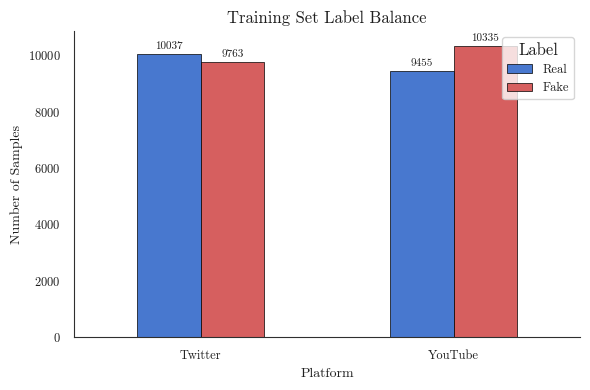

In [18]:
# Label balance bar chart
label_counts = combined_df.groupby(["platform", "label_name"]).size().unstack(fill_value=0)
label_counts = label_counts[["Real", "Fake"]]  # consistent order

fig, ax = plt.subplots(figsize=(6, 4))
label_counts.plot(kind="bar", ax=ax, color=["#4878CF", "#D65F5F"], edgecolor="black", linewidth=0.5)

ax.set_xlabel("Platform")
ax.set_ylabel("Number of Samples")
ax.set_title("Training Set Label Balance")
ax.set_xticklabels(["Twitter", "YouTube"], rotation=0)
ax.legend(title="Label", loc="upper right")

for container in ax.containers:
    ax.bar_label(container, fmt="%d", fontsize=8, padding=2)

fig.tight_layout()
paths = save_figure(fig, "label_balance")
print(f"Saved: {[p.name for p in paths]}")
plt.show()


## 6) Text Length Distribution

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


Saved: ['text_length_distribution.png', 'text_length_distribution.pdf']


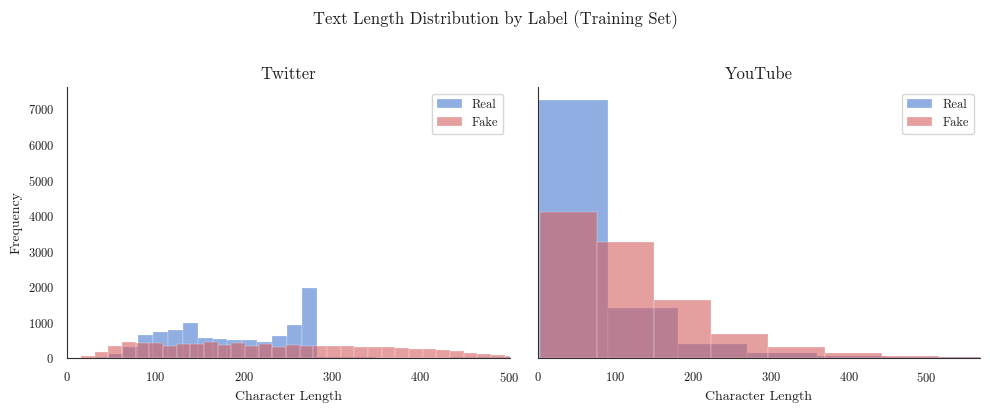

In [19]:
# Add character length
combined_df["char_length"] = combined_df["text"].fillna("").str.len()

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

for ax, (platform, pdf) in zip(axes, combined_df.groupby("platform")):
    for label, color in [("Real", "#4878CF"), ("Fake", "#D65F5F")]:
        subset = pdf[pdf["label_name"] == label]["char_length"]
        ax.hist(subset, bins=50, alpha=0.6, label=label, color=color, edgecolor="white", linewidth=0.3)
    ax.set_xlabel("Character Length")
    ax.set_title(f"{platform}")
    ax.legend()
    ax.set_xlim(0, pdf["char_length"].quantile(0.99))

axes[0].set_ylabel("Frequency")
fig.suptitle("Text Length Distribution by Label (Training Set)", fontsize=12, y=1.02)
fig.tight_layout()
paths = save_figure(fig, "text_length_distribution")
print(f"Saved: {[p.name for p in paths]}")
plt.show()


## 7) Training-Split Signal Prevalence for Real vs Fake

These figures audit the **stored training-split text** used by the final Twitter and YouTube pipelines.

- The notebook first checks whether the loaded split exposes an explicit raw/original text column; if not, it falls back to the stored `text` column.
- Each prevalence value is **binary per sample**: the share of Real or Fake samples containing the signal at least once.
- A companion guidance column maps the audited signal behavior to a preprocessing action: `CONVERT_TO_SPECIAL_TOKEN`, `NORMALIZE`, `REMOVE`, or `PRESERVE`.

**Purpose**: show which signals genuinely separate Real from Fake in the training data and how that evidence motivates preprocessing choices.

In [20]:
# Signal detectors (self-contained, notebook-local)
ALEF_VARIANT_CHARS = set("أإآٱ")
YEH_VARIANT_CHARS = set("ىی")
HAMZA_VARIANT_CHARS = set("ؤئء")
ARABIC_LETTER_VARIANT_CHARS = ALEF_VARIANT_CHARS | YEH_VARIANT_CHARS | HAMZA_VARIANT_CHARS

SIGNAL_URL_RE = re.compile(r"(?:https?://\S+|www\.\S+)", flags=re.IGNORECASE)
SIGNAL_MENTION_RE = re.compile(r"(?<!\w)@\w+")
SIGNAL_HASHTAG_RE = re.compile(r"(?<!\w)#\w+")
SIGNAL_EMOJI_RE = re.compile(r"[\U0001F1E6-\U0001F1FF\U0001F300-\U0001FAFF\U00002700-\U000027BF]")
SIGNAL_LATIN_RE = re.compile(r"[A-Za-z]")
SIGNAL_DIGIT_RE = re.compile(r"[\d\u0660-\u0669\u06F0-\u06F9]")
SIGNAL_DIACRITICS_RE = re.compile(r"[\u064B-\u0652\u0670\u065F]")
SIGNAL_TATWEEL_RE = re.compile(r"\u0640")
SIGNAL_CHAR_REPETITION_RE = re.compile(r"(.)\1{2,}")

SIGNAL_ORDER = [
    "Hashtags",
    "Mentions",
    "URLs",
    "Emojis",
    "Digits",
    "Latin / English",
    "Diacritics",
    "Tatweel",
    "Character repetition",
    "Arabic letter variants",
]

SIGNAL_DETECTORS = {
    "Hashtags": lambda text: bool(SIGNAL_HASHTAG_RE.search(text)),
    "Mentions": lambda text: bool(SIGNAL_MENTION_RE.search(text)),
    "URLs": lambda text: bool(SIGNAL_URL_RE.search(text)),
    "Emojis": lambda text: bool(SIGNAL_EMOJI_RE.search(text)),
    "Digits": lambda text: bool(SIGNAL_DIGIT_RE.search(text)),
    "Latin / English": lambda text: bool(SIGNAL_LATIN_RE.search(text)),
    "Diacritics": lambda text: bool(SIGNAL_DIACRITICS_RE.search(text)),
    "Tatweel": lambda text: bool(SIGNAL_TATWEEL_RE.search(text)),
    "Character repetition": lambda text: bool(SIGNAL_CHAR_REPETITION_RE.search(text)),
    "Arabic letter variants": lambda text: any(ch in ARABIC_LETTER_VARIANT_CHARS for ch in text),
}

STRUCTURAL_SIGNALS = {"Hashtags", "Mentions", "URLs", "Emojis", "Digits", "Latin / English"}
SIGNAL_TEXT_SOURCE_CANDIDATES = ["text_original", "original_text", "raw_text", "text_raw", "text"]

HANDLING_DISPLAY = {
    "CONVERT_TO_SPECIAL_TOKEN": "Special token",
    "NORMALIZE": "Normalize",
    "REMOVE": "Remove",
    "PRESERVE": "Preserve",
}
HANDLING_COLORS = {
    "CONVERT_TO_SPECIAL_TOKEN": "#2F6C8F",
    "NORMALIZE": "#36796B",
    "REMOVE": "#6E6E6E",
    "PRESERVE": "#8A4F2D",
}

print(f"Signal detectors defined: {len(SIGNAL_DETECTORS)}")
print(f"Stable signal order: {SIGNAL_ORDER}")

Signal detectors defined: 10
Stable signal order: ['Hashtags', 'Mentions', 'URLs', 'Emojis', 'Digits', 'Latin / English', 'Diacritics', 'Tatweel', 'Character repetition', 'Arabic letter variants']


In [21]:
from matplotlib import transforms



def resolve_signal_text_column(df):
    """Prefer an explicit raw/original column when it exists in the loaded split."""
    for column in SIGNAL_TEXT_SOURCE_CANDIDATES:
        if column in df.columns:
            if column == "text":
                note = "stored training-split `text` field (only available text source in the split file)"
            else:
                note = f"`{column}`"
            return column, note
    raise KeyError("No text column available for signal audit.")



def recommend_signal_handling(signal_name, real_rate, fake_rate):
    """Map audited signal behavior to a preprocessing recommendation."""
    max_rate = max(real_rate, fake_rate)
    mean_rate = (real_rate + fake_rate) / 2.0
    gap = abs(fake_rate - real_rate)

    if signal_name in STRUCTURAL_SIGNALS:
        if max_rate < 0.005:
            return "REMOVE", "Near-absent structural marker in the stored split."
        return "CONVERT_TO_SPECIAL_TOKEN", "Structural cue is better preserved as a typed placeholder than as raw surface forms."

    if signal_name == "Tatweel":
        if max_rate < 0.05:
            return "REMOVE", "Pure elongation mark with very low prevalence."
        return "NORMALIZE", "Decorative elongation should be standardized."

    if signal_name == "Diacritics":
        if gap >= 0.12:
            return "PRESERVE", "Large class gap suggests that the original stylistic form may itself be informative."
        if max_rate < 0.01:
            return "REMOVE", "Effectively absent after the stored data stage."
        return "NORMALIZE", "Orthographic variation can be standardized when the class gap is weak."

    if signal_name == "Arabic letter variants":
        if gap >= 0.12:
            return "PRESERVE", "Variant forms show a material class gap, so preserving them may retain signal."
        return "NORMALIZE", "Very common variants are better standardized when their class gap is modest."

    if signal_name == "Character repetition":
        if mean_rate < 0.01:
            return "REMOVE", "Stylistic repetition is effectively absent."
        if gap >= 0.12:
            return "PRESERVE", "Repetition level shows a large class gap."
        return "NORMALIZE", "Cap elongation while retaining lexical content."

    return "NORMALIZE", "Default orthographic cleanup."



def compute_signal_audit(df, label_col="label_name"):
    """Compute per-sample signal prevalence for Real vs Fake using the best available text source."""
    text_col, text_source_note = resolve_signal_text_column(df)
    texts = df[text_col].fillna("").astype(str)
    labels = df[label_col].astype(str)

    real_mask = labels.eq("Real")
    fake_mask = labels.eq("Fake")
    n_real = int(real_mask.sum())
    n_fake = int(fake_mask.sum())

    rows = []
    for signal_name in SIGNAL_ORDER:
        detector = SIGNAL_DETECTORS[signal_name]
        signal_present = texts.apply(detector)
        real_count = int((signal_present & real_mask).sum())
        fake_count = int((signal_present & fake_mask).sum())
        real_rate = real_count / n_real if n_real else 0.0
        fake_rate = fake_count / n_fake if n_fake else 0.0
        abs_gap = abs(fake_rate - real_rate)
        favored_class = "Fake" if fake_rate > real_rate else ("Real" if real_rate > fake_rate else "Equal")
        recommended_handling, guidance_reason = recommend_signal_handling(signal_name, real_rate, fake_rate)

        rows.append({
            "signal_category": signal_name,
            "text_source": text_col,
            "text_source_note": text_source_note,
            "prevalence_unit": "binary per-sample prevalence",
            "real_count": real_count,
            "fake_count": fake_count,
            "real_rate": real_rate,
            "fake_rate": fake_rate,
            "abs_gap": abs_gap,
            "favored_class": favored_class,
            "recommended_handling": recommended_handling,
            "recommended_handling_display": HANDLING_DISPLAY[recommended_handling],
            "guidance_reason": guidance_reason,
        })

    return pd.DataFrame(rows), text_col, text_source_note



def format_percent_label(value):
    return f"{value:.1f}%"



def plot_signal_guidance_heatmap(audit_df, platform_label, text_source_note):
    """Plot a paper-ready heatmap with prevalence, gap, and preprocessing guidance."""
    plot_df = audit_df.copy()
    plot_df["Real"] = plot_df["real_rate"] * 100.0
    plot_df["Fake"] = plot_df["fake_rate"] * 100.0
    plot_df["Abs. gap"] = plot_df["abs_gap"] * 100.0
    plot_df = plot_df.set_index("signal_category").loc[SIGNAL_ORDER].reset_index()

    heatmap_values = plot_df[["Real", "Fake", "Abs. gap"]]
    annot_values = heatmap_values.applymap(format_percent_label)

    n_rows = len(plot_df)
    fig = plt.figure(figsize=(9.4, max(4.8, 0.48 * n_rows + 0.8)), constrained_layout=True)
    gs = fig.add_gridspec(1, 2, width_ratios=[1.45, 1.0], wspace=0.08)
    ax_heat = fig.add_subplot(gs[0, 0])
    ax_guidance = fig.add_subplot(gs[0, 1])

    sns.heatmap(
        heatmap_values,
        annot=annot_values,
        fmt="",
        cmap="YlOrRd",
        vmin=0.0,
        vmax=100.0,
        linewidths=0.8,
        linecolor="white",
        cbar_kws={"label": "Prevalence / gap (%)", "shrink": 0.82},
        annot_kws={"fontsize": 9},
        ax=ax_heat,
    )

    ax_heat.set_xlabel("Class / comparison")
    ax_heat.set_ylabel("Signal category")
    ax_heat.set_title(f"Signal Prevalence and Preprocessing Guidance - {platform_label}", pad=12)
    ax_heat.set_xticklabels(["Real", "Fake", "Abs. gap"], rotation=0)
    ax_heat.set_yticklabels(plot_df["signal_category"], rotation=0)

    ax_guidance.set_xlim(0, 1)
    ax_guidance.set_ylim(ax_heat.get_ylim())
    ax_guidance.axis("off")
    row_transform = transforms.blended_transform_factory(ax_guidance.transAxes, ax_guidance.transData)
    ax_guidance.text(0.0, 1.01, "Handling", transform=ax_guidance.transAxes, ha="left", va="bottom", fontsize=10, fontweight="semibold")

    for row_idx, row in enumerate(plot_df.itertuples(index=False)):
        y_position = row_idx + 0.5
        handling = row.recommended_handling
        ax_guidance.text(
            0.0,
            y_position,
            HANDLING_DISPLAY[handling],
            transform=row_transform,
            ha="left",
            va="center",
            fontsize=9.1,
            color=HANDLING_COLORS[handling],
            fontweight="semibold",
        )

    return fig


print("Signal-audit helpers ready.")

Signal-audit helpers ready.


'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


Twitter heatmap uses `text` with binary per-sample prevalence. Saved: ['twitter_signal_prevalence_real_vs_fake.png', 'twitter_signal_prevalence_real_vs_fake.pdf'], twitter_signal_discriminator_notes.csv


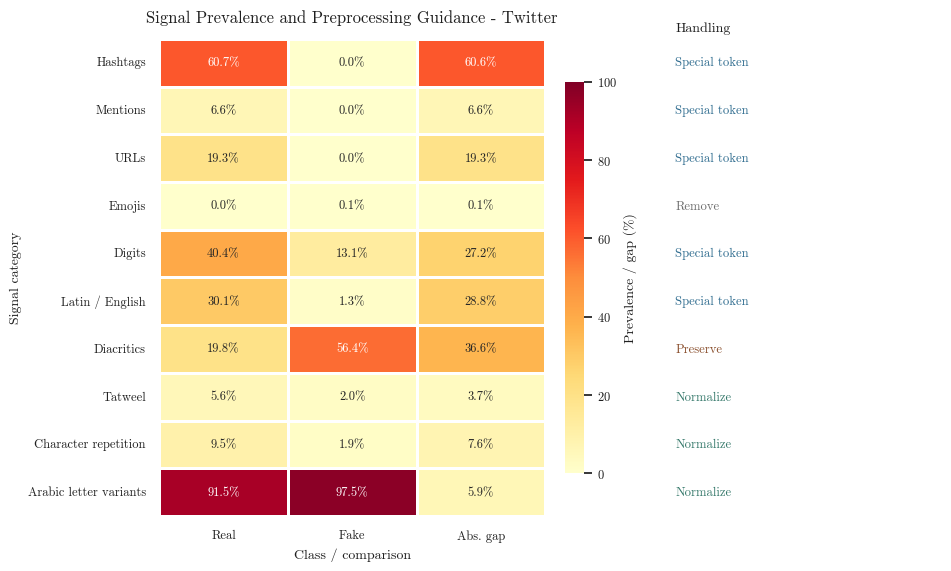

In [22]:
# Twitter signal prevalence and preprocessing guidance
twitter_signal_audit, twitter_signal_text_col, twitter_signal_text_note = compute_signal_audit(twitter_train)

fig = plot_signal_guidance_heatmap(twitter_signal_audit, "Twitter", twitter_signal_text_note)
paths = save_figure(fig, "twitter_signal_prevalence_real_vs_fake")
csv_path = save_table(twitter_signal_audit, "twitter_signal_discriminator_notes")
print(
    f"Twitter heatmap uses `{twitter_signal_text_col}` with binary per-sample prevalence. "
    f"Saved: {[p.name for p in paths]}, {csv_path.name}"
)
plt.show()

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


YouTube heatmap uses `text` with binary per-sample prevalence. Saved: ['youtube_signal_prevalence_real_vs_fake.png', 'youtube_signal_prevalence_real_vs_fake.pdf'], youtube_signal_discriminator_notes.csv


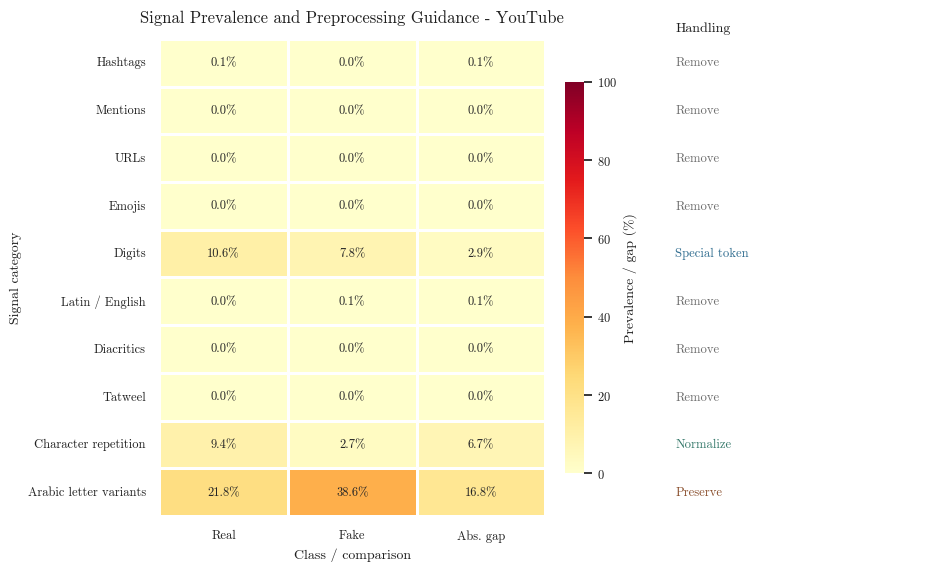

In [23]:
# YouTube signal prevalence and preprocessing guidance
youtube_signal_audit, youtube_signal_text_col, youtube_signal_text_note = compute_signal_audit(youtube_train)

fig = plot_signal_guidance_heatmap(youtube_signal_audit, "YouTube", youtube_signal_text_note)
paths = save_figure(fig, "youtube_signal_prevalence_real_vs_fake")
csv_path = save_table(youtube_signal_audit, "youtube_signal_discriminator_notes")
print(
    f"YouTube heatmap uses `{youtube_signal_text_col}` with binary per-sample prevalence. "
    f"Saved: {[p.name for p in paths]}, {csv_path.name}"
)
plt.show()

**How to read the guidance column**:
- `Special token`: the signal is structurally useful, but the exact surface form is less important than preserving its presence.
- `Normalize`: standardize orthographic variation while keeping the underlying lexical content.
- `Remove`: the signal is absent or close to absent in the audited split, so keeping it adds little analytical value.
- `Preserve`: the raw form shows a material Real/Fake gap and may itself carry discriminative information.

## 8) Fake-Only Deception Subtype Distribution

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


Deception subtype figure excludes Twitter=`original` and YouTube=`none` before plotting. Saved: ['deception_subtype_distribution.png', 'deception_subtype_distribution.pdf']


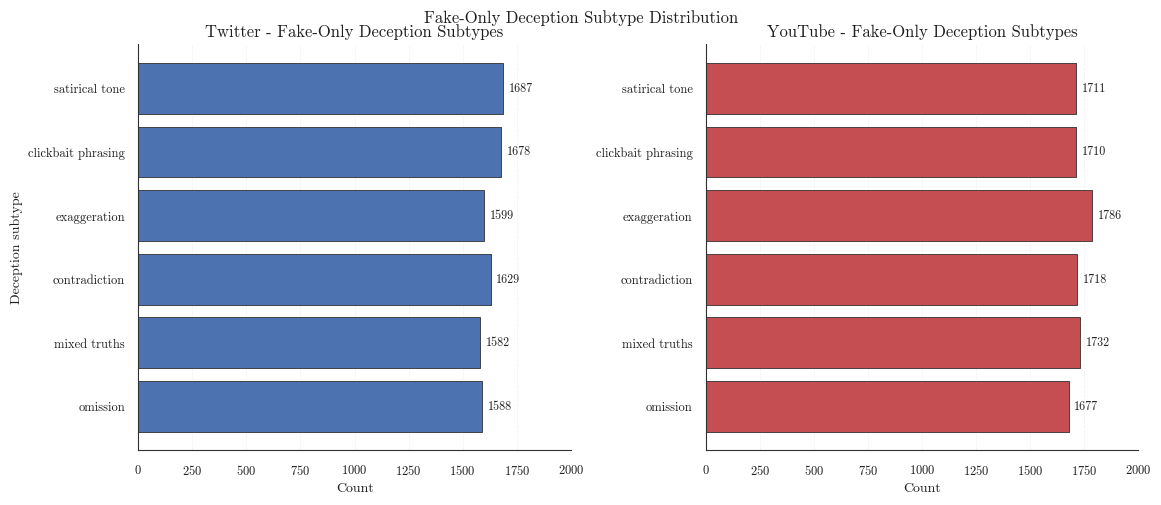

In [24]:
# Fake-only deception subtype distribution
SHOW_DECEPTION_SUBTYPE = False
NON_FAKE_DECEPTION_TYPES = {"Twitter": {"original"}, "YouTube": {"none"}}



def compute_fake_only_deception_counts(df, platform_label):
    if "deception_type" not in df.columns:
        return pd.Series(dtype="int64")

    fake_only = df[df["label_name"] == "Fake"].copy()
    if fake_only.empty:
        return pd.Series(dtype="int64")

    subtype_series = fake_only["deception_type"].fillna("").astype(str).str.strip()
    subtype_series = subtype_series[~subtype_series.isin(NON_FAKE_DECEPTION_TYPES.get(platform_label, set()) | {"", "nan", "None"})]
    return subtype_series.value_counts()



twitter_fake_type_counts = compute_fake_only_deception_counts(twitter_train, "Twitter")
youtube_fake_type_counts = compute_fake_only_deception_counts(youtube_train, "YouTube")
SHOW_DECEPTION_SUBTYPE = not twitter_fake_type_counts.empty or not youtube_fake_type_counts.empty

if SHOW_DECEPTION_SUBTYPE:
    combined_order = pd.concat(
        [
            twitter_fake_type_counts.rename("Twitter"),
            youtube_fake_type_counts.rename("YouTube"),
        ],
        axis=1,
    ).fillna(0)
    deception_order = combined_order.sum(axis=1).sort_values(ascending=False).index.tolist()

    fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.8), sharex=True, constrained_layout=True)
    color_map = {"Twitter": "#4C72B0", "YouTube": "#C44E52"}
    max_count = max(
        twitter_fake_type_counts.max() if not twitter_fake_type_counts.empty else 0,
        youtube_fake_type_counts.max() if not youtube_fake_type_counts.empty else 0,
    )

    for ax, platform_label, counts in zip(
        axes,
        ["Twitter", "YouTube"],
        [twitter_fake_type_counts, youtube_fake_type_counts],
    ):
        plot_counts = counts.reindex(deception_order[::-1], fill_value=0)
        ax.barh(
            plot_counts.index,
            plot_counts.values,
            color=color_map[platform_label],
            edgecolor="#2F2F2F",
            linewidth=0.6,
        )
        ax.set_title(f"{platform_label} - Fake-Only Deception Subtypes")
        ax.set_xlabel("Count")
        ax.set_xlim(0, max_count * 1.12 if max_count else 1)
        ax.grid(axis="x", alpha=0.25, linestyle="--", linewidth=0.6)

        for bar in ax.patches:
            width = int(bar.get_width())
            if width > 0:
                ax.text(width + max(10, max_count * 0.015), bar.get_y() + bar.get_height() / 2, f"{width}", va="center", ha="left", fontsize=8.7)

    axes[0].set_ylabel("Deception subtype")
    fig.suptitle("Fake-Only Deception Subtype Distribution", y=1.02)
    paths = save_figure(fig, "deception_subtype_distribution")
    print(
        "Deception subtype figure excludes Twitter=`original` and YouTube=`none` before plotting. "
        f"Saved: {[p.name for p in paths]}"
    )
    plt.show()
else:
    print("Deception subtype analysis skipped (metadata missing or no fake-only subtype variation).")

## 9) Export Summary

In [25]:
# Final summary
print("=" * 60)
print("EDA NOTEBOOK SUMMARY")
print("=" * 60)
print(f"Dataset root: {DATASET_ROOT}")
print(f"Output root:  {OUTPUT_ROOT}")
print()
print("Figures saved:")
for f in sorted((OUTPUT_ROOT / "figures").glob("*.png")):
    print(f"  - {f.name}")
print()
print("Tables saved:")
for f in sorted((OUTPUT_ROOT / "tables").glob("*.csv")):
    print(f"  - {f.name}")
print()
print("Sections included:")
print("  - Dataset overview")
print("  - Label balance")
print("  - Text length distribution")
print("  - Signal prevalence + preprocessing guidance heatmaps (Twitter, YouTube)")
print(f"  - Fake-only deception subtype: {'included' if SHOW_DECEPTION_SUBTYPE else 'skipped'}")
print()
print("Dependencies: numpy, pandas, matplotlib, seaborn (CPU-only, no GPU)")
print("=" * 60)

EDA NOTEBOOK SUMMARY
Dataset root: c:\Users\ahrhq\OneDrive - KFUPM\GADD\GADD_Project\Dataset
Output root:  c:\Users\ahrhq\OneDrive - KFUPM\GADD\GADD_Project\Final_Pipeline\Output\eda

Figures saved:
  - deception_subtype_distribution.png
  - label_balance.png
  - text_length_distribution.png
  - twitter_signal_prevalence_real_vs_fake.png
  - youtube_signal_prevalence_real_vs_fake.png

Tables saved:
  - dataset_overview_train_split.csv
  - preprocessing_examples_twitter.csv
  - preprocessing_examples_youtube.csv
  - preprocessing_tokenization_comparison.csv
  - twitter_signal_discriminator_notes.csv
  - youtube_signal_discriminator_notes.csv

Sections included:
  - Dataset overview
  - Label balance
  - Text length distribution
  - Signal prevalence + preprocessing guidance heatmaps (Twitter, YouTube)
  - Fake-only deception subtype: included

Dependencies: numpy, pandas, matplotlib, seaborn (CPU-only, no GPU)
